In [81]:
# Imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import duckdb
import numpy as np

sns.set_theme(style="whitegrid")

conn = duckdb.connect("../data/duckdb.mimic")
admissions_df = conn.execute("SELECT * FROM admissions WHERE deathtime IS NULL;").df()
patients_df = conn.execute("SELECT subject_id, gender, anchor_age AS age FROM patients;").df()

patient_admissions = admissions_df.merge(patients_df, on="subject_id")
patient_admissions.info()

<class 'pandas.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   subject_id            260 non-null    int64         
 1   hadm_id               260 non-null    int64         
 2   admittime             260 non-null    datetime64[us]
 3   dischtime             260 non-null    datetime64[us]
 4   deathtime             0 non-null      datetime64[us]
 5   admission_type        260 non-null    str           
 6   admit_provider_id     260 non-null    str           
 7   admission_location    260 non-null    str           
 8   discharge_location    218 non-null    str           
 9   insurance             260 non-null    str           
 10  language              260 non-null    str           
 11  marital_status        249 non-null    str           
 12  race                  260 non-null    str           
 13  edregtime             174 non-n

# Exploratory Data Analysis - MIMIC-IV Demo
**Project:** 30-Day Hospital Readmission Risk Predictor \
**Dataset:** [MIMIC-IV Demo v2.2](https://physionet.org/content/mimic-iv-demo/2.2/) (PhysioNet)

## Overview
This notebook explores the MIMIC-IV Demo dataset to understand the structure, distributions, and quality of the clinical data before modeling. The goal is to:
 
- Understand the schema and relationships between key tables
- Characterize the study cohort (demographics, admission patterns)
- Identify data quality issues (missingness, outliers, skew)
- Surface early signals of features likely predictive of 30-day readmission
  
MIMIC-IV (Medical Information Mart for Intensive Care) is a large, de-identified database of ICU patients admitted to Beth Israel Deaconess Medical Center in Boston. The demo subset contains data for approximately 100 patients and mirrors the full dataset's schema exactly, making it ideal for pipeline development.


## 1. Finding Readmissions
To construct our outcome label, we find patients who were readmitted to the hospital within 30 days of discharge and exclude all in-hospital deaths as these patients cannot be readmitted. \
The readmission rate gives a sense of class balance before modeling. 

In [82]:
patient_admissions["admittime"] = pd.to_datetime(patient_admissions["admittime"])
patient_admissions["dischtime"] = pd.to_datetime(patient_admissions["dischtime"])

df = patient_admissions.sort_values("admittime")

first_admission = df.groupby("subject_id").first().reset_index()

def was_readmitted(row):
    subsequent = patient_admissions[
        (patient_admissions["subject_id"] == row["subject_id"]) & 
        (patient_admissions["admittime"] > row["dischtime"]) & 
        (patient_admissions["admittime"] <= row["dischtime"] + pd.Timedelta(days=30))
    ]
    return int(len(subsequent) > 0)

first_admission["readmitted_30d"] = first_admission.apply(was_readmitted, axis=1)
df = first_admission.copy()

rate = first_admission["readmitted_30d"].sum() / len(df)
print(f"Readmission rate: {rate}")

Readmission rate: 0.15789473684210525


## Observations
- The readmission rate for this cohort is **~15.8%**, consistent with the 15-20% range reported in published MIMIC-based studies and real-world ICU populations.
- This confirms a meaningful class imbalance — roughly 5 non-readmitted patients for every 1 readmitted patient. Class imbalance handling via `class_weight="balanced"` in logistic regression will be applied during modeling.
- Modeling results should be interpreted as proof-of-concept given the demo sample size of 260 patients.

## 2. Age Distribution
Examine the age distribution of patients, and whether age is correlated with readmission risk.

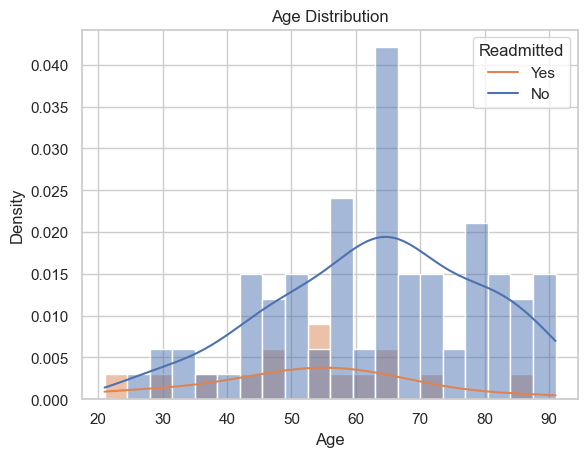

In [83]:
sns.histplot(data=df, x='age', bins=20, stat='density', kde=True, hue='readmitted_30d')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend(title='Readmitted', labels=["Yes", "No"])
plt.show()

## Observations
- Non-readmitted patients (blue) heavily dominate and peak sharply around 60-65, with a broad distribution from 45-90.
- Readmitted patients (orange) are sparse and nearly flat across all ages due to the small positive class. No strong age signal is visible.
- Age alone is not a reliable standalone predictor at this sample size.

## 3. Length of Stay
Find the duration of the hospital stay in days, and examine the distribution. 

In [84]:
df['los_days'] = round((df['dischtime'] - df['admittime']).dt.total_seconds() / 86400, 2)
df['los_days'].describe()

count    95.000000
mean      7.869263
std       7.336632
min       0.230000
25%       3.360000
50%       5.600000
75%       9.715000
max      44.930000
Name: los_days, dtype: float64

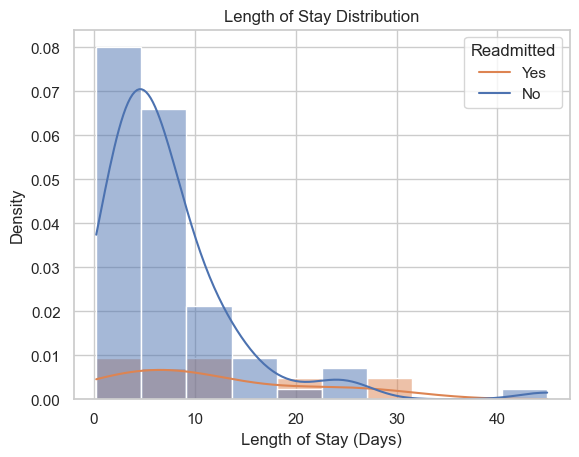

In [85]:
sns.histplot(data=df, x='los_days', stat='density', kde=True, bins=10, hue='readmitted_30d')
plt.title('Length of Stay Distribution')
plt.xlabel('Length of Stay (Days)')
plt.ylabel('Density')
plt.legend(title='Readmitted', labels=["Yes", "No"])
plt.show()

## Observations
- Non-readmitted patients (blue) are heavily right-skewed, peaking at 0-5 days and dropping off steeply — most patients who were not
  readmitted had short stays.
- Readmitted patients (orange) show a much flatter, more uniform distribution extending all the way to 30+ days, suggesting longer
  stays are associated with readmission in this corrected cohort.
- Log-transforming LOS seems appropriate given the right skew.

## 4. Gender Readmission Rate
Examine whether the readmission rate between genders differ. Gender should be included as a predictive feature, but also as an attribute for fairness evaluation. 

In [86]:
gender_rates = df.groupby('gender')['readmitted_30d'].agg(["mean", "size"]).reset_index()
gender_rates.head()

,gender,mean,size
0,F,0.238095,42
1,M,0.094340,53


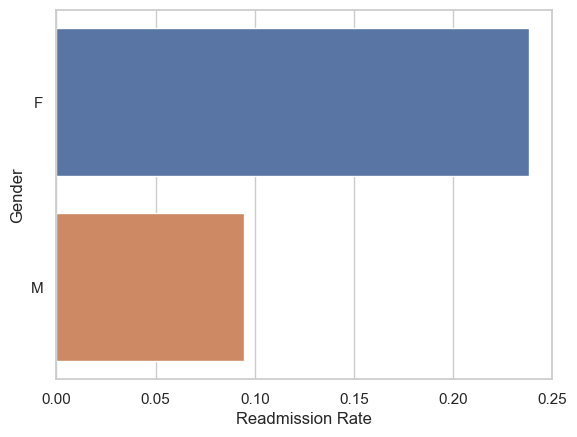

In [87]:
sns.barplot(data=gender_rates, x='mean', y='gender', hue='gender')
plt.xlabel('Readmission Rate')
plt.ylabel('Gender')
plt.show()

## Observations
- Female patients show a substantially higher readmission rate compared to male patients.
- This is the largest demographic disparity observed across all features and warrants close attention in the fairness evaluation.
- No causal claims should be drawn — the difference may reflect underlying differences in comorbidity burden or admission type between groups.

## 5. Readmission Rate by Insurance
Insurance is potentially both a predictive signal and a proxy for socioeconomic status. Examine if readmission rate varies across insurance categories.

In [88]:
insurance_rates = df.groupby('insurance')['readmitted_30d'].agg(['mean', 'size']).reset_index().sort_values('mean', ascending=False)
insurance_rates

,insurance,mean,size
2,Other,0.185185,54
0,Medicaid,0.142857,7
1,Medicare,0.117647,34


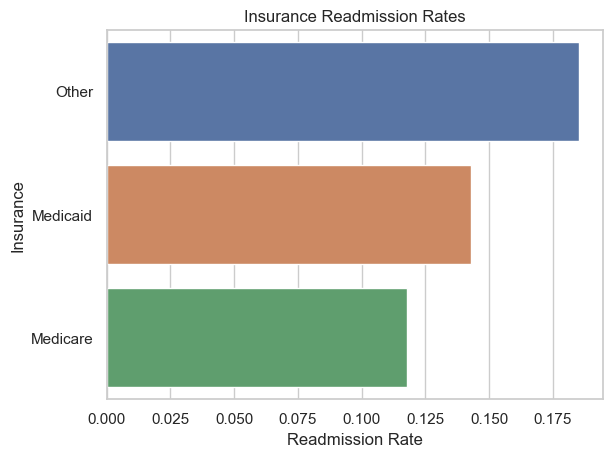

In [89]:
sns.barplot(data=insurance_rates, x='mean', y='insurance', hue='insurance')
plt.title('Insurance Readmission Rates')
plt.xlabel('Readmission Rate')
plt.ylabel('Insurance')
plt.show()

## Observations
- Other insurance shows the highest readmission rate, followed by Medicaid and Medicare .
- The Medicaid group is very small (n=7), making its estimate highly unreliable.
- The spread across insurance types is narrow (~7 percentage points), suggesting insurance type is not a strong standalone predictor.
- Insurance remains important as a fairness attribute given its role as a proxy for socioeconomic status.

## 6. Admission Type
Admission type captures the urgency and context of the initial hospitalization. Emergency admissions represent unplanned, acute events while elective admissions are scheduled procedures. We would expect emergency admissions to carry higher readmission risk given the acute nature of the underlying condition.

In [90]:
type_rates = df.groupby('admission_type')['readmitted_30d'].agg(['mean', 'size']).sort_values('mean', ascending=False).reset_index()
type_rates

,admission_type,mean,size
0,DIRECT EMER.,0.333333,3
1,EU OBSERVATION,0.250000,4
2,EW EMER.,0.190476,42
3,OBSERVATION ADMIT,0.166667,6
4,URGENT,0.150000,20
5,SURGICAL SAME DAY ADMISSION,0.100000,10
6,AMBULATORY OBSERVATION,0.000000,3
7,ELECTIVE,0.000000,7


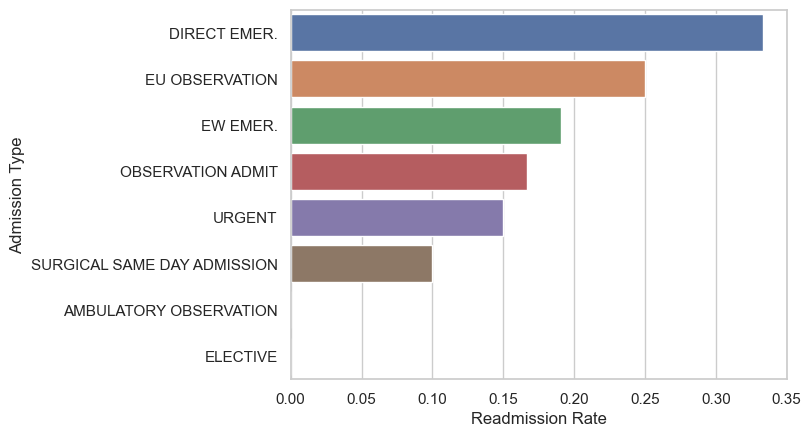

In [91]:
sns.barplot(data=type_rates, x='mean', y='admission_type', hue='admission_type')
plt.xlabel('Readmission Rate')
plt.ylabel('Admission Type')
plt.show()

## Observations
- Direct Emer. shows the highest readmission rate, though the very small group size makes this unreliable.
- EW Emer. is the largest and most reliable emergency group with a readmission rate of ~19%, confirming emergency admissions carry
  higher risk.
- EU Observation also shows a high rate (~25%, n=4) — likely reflecting patients discharged before full stabilization.
- Elective and Ambulatory Observation admissions show 0% readmission.
- These 8 categories can possibly be consolidated into 4 buckets during feature engineering: Emergency, Observation, Elective, and Surgical.

## 7. Diagnosis Count
The number of ICD diagnosis codes assigned at discharge is a signal for comorbidity burden. Patients with more diagnoses are generally sicker and more complex. I expect higher diagnosis counts to correlate with higher readmission risk.

In [92]:
diagnoses = conn.execute('SELECT * FROM diagnoses_icd').df()

diagnosis_counts = diagnoses.groupby('hadm_id')['icd_code'].count().reset_index().rename(columns={'icd_code': 'n_diagnoses'})
diagnosis_counts
df = df.merge(diagnosis_counts, on='hadm_id', how='left')

df['n_diagnoses'] = df['n_diagnoses'].fillna(0)

df.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,...,marital_status,race,edregtime,edouttime,hospital_expire_flag,gender,age,readmitted_30d,los_days,n_diagnoses
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaT,URGENT,P874LG,TRANSFER FROM HOSPITAL,HOME,Other,...,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,F,52,0,0.79,8
1,10001217,24597018,2157-11-18 22:56:00,2157-11-25 18:00:00,NaT,EW EMER.,P4645A,EMERGENCY ROOM,HOME HEALTH CARE,Other,...,MARRIED,WHITE,2157-11-18 17:38:00,2157-11-19 01:24:00,0,F,55,1,6.79,10
2,10001725,25563031,2110-04-11 15:08:00,2110-04-14 15:00:00,NaT,EW EMER.,P35SU0,PACU,HOME,Other,...,MARRIED,WHITE,NaT,NaT,0,F,46,0,2.99,18
3,10002428,25797028,2155-07-14 19:15:00,2155-07-15 18:37:00,NaT,EU OBSERVATION,P64TOH,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,...,WIDOWED,WHITE,2155-07-14 16:58:00,2155-07-14 20:04:00,0,F,80,0,0.97,8
4,10002495,24982426,2141-05-22 20:17:00,2141-05-29 17:41:00,NaT,URGENT,P79SJ2,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicare,...,MARRIED,UNKNOWN,NaT,NaT,0,M,81,0,6.89,26


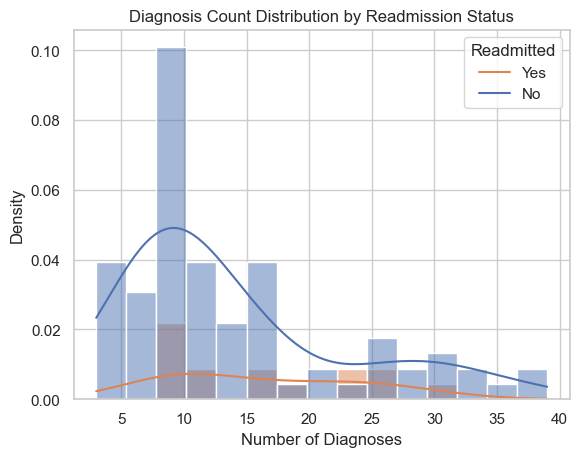

In [93]:
sns.histplot(data=df, x='n_diagnoses', hue='readmitted_30d', bins=15, kde=True, stat='density')
plt.title('Diagnosis Count Distribution by Readmission Status')
plt.legend(title='Readmitted', labels=['Yes', 'No'])
plt.xlabel('Number of Diagnoses')
plt.ylabel('Density')
plt.show()

## Observations
- Non-readmitted patients (blue) peak sharply at 8-10 diagnoses and drop off steeply, while readmitted patients (orange) are nearly flat
  across the full range with a slight right tail.
- The distributions largely overlap, suggesting diagnosis count is a weaker signal.
- Log-transformation is still appropriate given the right skew.

## 8. Lab Values
Lab results could be strong predictors of patient deterioration, and therefore, a strong signal for readmission risk. 

In [94]:
lab_events = conn.execute('SELECT * FROM labevents;').df()

ITEM_IDS = {
    50912: "creatinine",
    50931: "glucose",
    51222: "hemoglobin",
    50983: "sodium",
    50971: "potassium",
    51301: "wbc",
}

labs = lab_events[lab_events['itemid'].isin(ITEM_IDS.keys())]
labs['lab_name'] = labs['itemid'].map(ITEM_IDS)
labs["charttime"] = pd.to_datetime(labs["charttime"])

labs = (
    labs.sort_values("charttime")
    .groupby(["hadm_id", "lab_name"])["valuenum"]
    .last()
    .reset_index()
)

labs_pivot = labs.pivot_table(index='hadm_id', columns=['lab_name'], values='valuenum').reset_index()

df = df.merge(labs_pivot, on='hadm_id', how='left')
df.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,...,age,readmitted_30d,los_days,n_diagnoses,creatinine,glucose,hemoglobin,potassium,sodium,wbc
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaT,URGENT,P874LG,TRANSFER FROM HOSPITAL,HOME,Other,...,52,0,0.79,8,0.3,99.0,12.7,4.5,137.0,4.2
1,10001217,24597018,2157-11-18 22:56:00,2157-11-25 18:00:00,NaT,EW EMER.,P4645A,EMERGENCY ROOM,HOME HEALTH CARE,Other,...,55,1,6.79,10,0.4,95.0,12.9,4.2,140.0,10.3
2,10001725,25563031,2110-04-11 15:08:00,2110-04-14 15:00:00,NaT,EW EMER.,P35SU0,PACU,HOME,Other,...,46,0,2.99,18,0.9,124.0,12.0,3.7,140.0,11.1
3,10002428,25797028,2155-07-14 19:15:00,2155-07-15 18:37:00,NaT,EU OBSERVATION,P64TOH,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,...,80,0,0.97,8,0.8,100.0,11.8,4.4,136.0,6.0
4,10002495,24982426,2141-05-22 20:17:00,2141-05-29 17:41:00,NaT,URGENT,P79SJ2,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicare,...,81,0,6.89,26,1.1,165.0,11.2,4.3,136.0,11.2


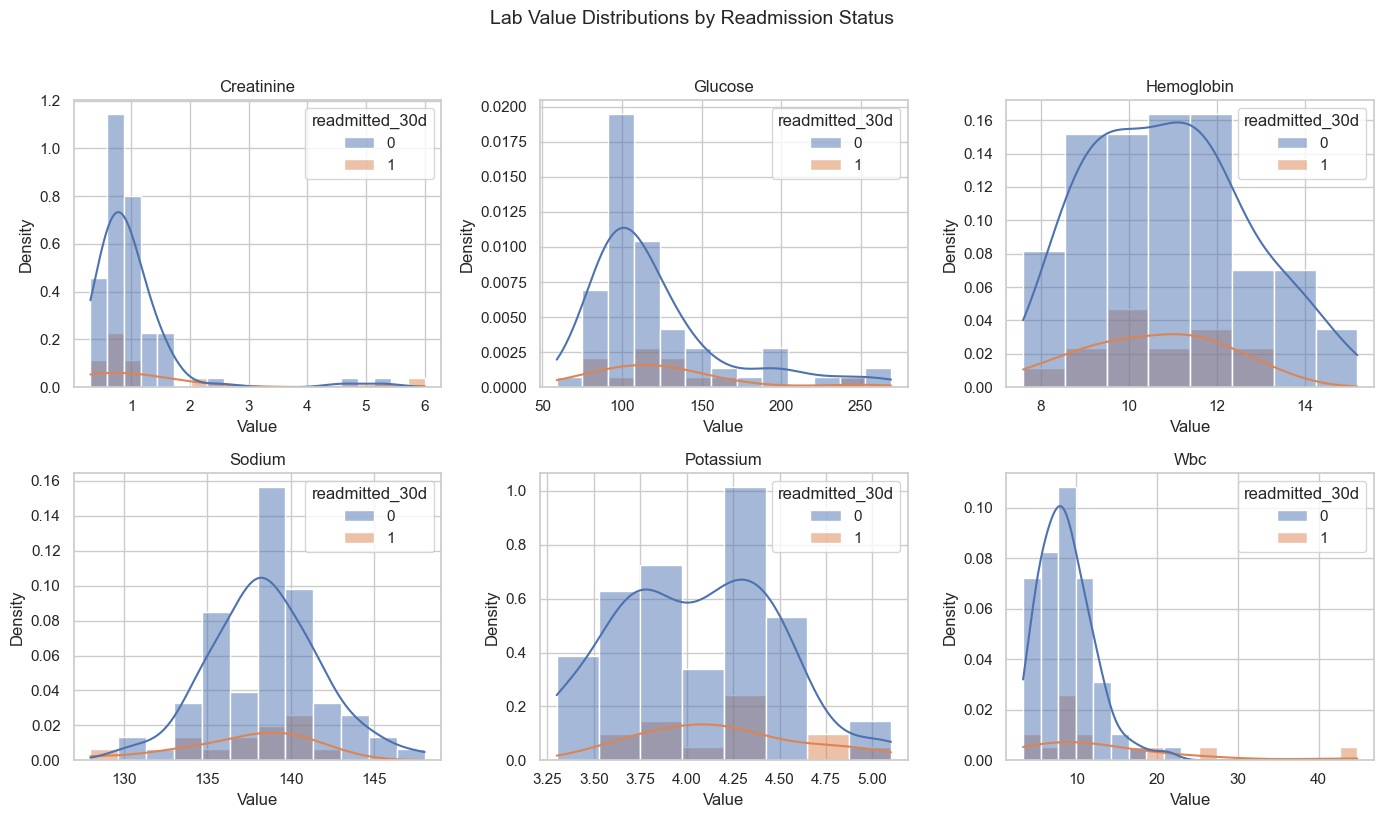

In [95]:
lab_names = list(ITEM_IDS.values())

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, lab in enumerate(lab_names):
    sns.histplot(data=df, x=lab, hue='readmitted_30d', kde=True, stat='density', ax=axes[i])
    axes[i].set_title(lab.capitalize())
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')

plt.suptitle("Lab Value Distributions by Readmission Status", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## Observations
- The small readmitted group (n=41) makes visual separation difficult across all labs — correlation matrix values are more reliable guides to feature importance than visual inspection here.

## 9. Prescription Type and Count
The number of unique prescriptions given during admission can signal complications and comorbidity burden, both of which can possibly predcit readmission. Also, I want to flag the presence of high-risk medications (such as anticoagulants, insulin, etc.).

In [96]:
prescriptions = conn.execute('SELECT * FROM prescriptions;').df()
prescriptions.head()

rx_counts = prescriptions.groupby('hadm_id')['drug'].nunique().reset_index().rename(columns={'drug': 'n_drugs'})
df = df.merge(rx_counts, on='hadm_id', how='left')

df.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,...,readmitted_30d,los_days,n_diagnoses,creatinine,glucose,hemoglobin,potassium,sodium,wbc,n_drugs
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaT,URGENT,P874LG,TRANSFER FROM HOSPITAL,HOME,Other,...,0,0.79,8,0.3,99.0,12.7,4.5,137.0,4.2,12.0
1,10001217,24597018,2157-11-18 22:56:00,2157-11-25 18:00:00,NaT,EW EMER.,P4645A,EMERGENCY ROOM,HOME HEALTH CARE,Other,...,1,6.79,10,0.4,95.0,12.9,4.2,140.0,10.3,23.0
2,10001725,25563031,2110-04-11 15:08:00,2110-04-14 15:00:00,NaT,EW EMER.,P35SU0,PACU,HOME,Other,...,0,2.99,18,0.9,124.0,12.0,3.7,140.0,11.1,35.0
3,10002428,25797028,2155-07-14 19:15:00,2155-07-15 18:37:00,NaT,EU OBSERVATION,P64TOH,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,...,0,0.97,8,0.8,100.0,11.8,4.4,136.0,6.0,6.0
4,10002495,24982426,2141-05-22 20:17:00,2141-05-29 17:41:00,NaT,URGENT,P79SJ2,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicare,...,0,6.89,26,1.1,165.0,11.2,4.3,136.0,11.2,52.0


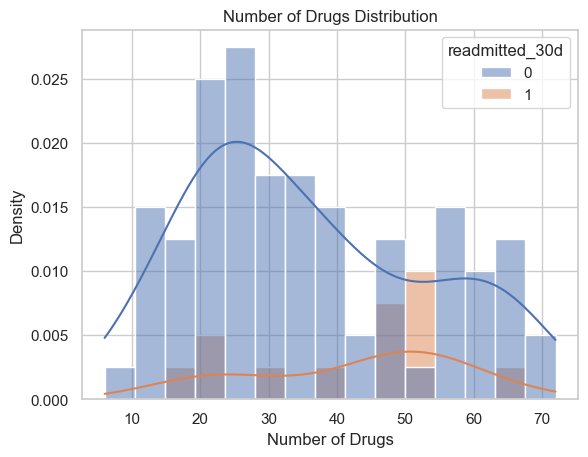

In [97]:
sns.histplot(data=df, x='n_drugs', bins=15, hue='readmitted_30d', stat='density', kde=True)
plt.title('Number of Drugs Distribution')
plt.xlabel('Number of Drugs')
plt.ylabel('Density')
plt.show()

In [98]:
HIGH_RISK_DRUGS = [
    "warfarin", "apixaban", "rivaroxaban", "heparin", "insulin", "metformin", "lorazepam", "clonazepam",
    "digoxin", "lithium", "vancomycin", "methotrexate", "fentanyl", "morphine", "doxorubicin", "furosemide",
    "amoxicillin"
]

pattern = "|".join(HIGH_RISK_DRUGS)
prescriptions["is_high_risk"] = (
    prescriptions["drug"].str.lower().str.contains(pattern, na=False)
)

high_risk_flag = (
    prescriptions.groupby("hadm_id")["is_high_risk"]
    .any()
    .astype(int)
    .reset_index()
    .rename(columns={"is_high_risk": "high_risk_drug"})
)

df = df.merge(high_risk_flag, on='hadm_id', how='left')

df.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,...,los_days,n_diagnoses,creatinine,glucose,hemoglobin,potassium,sodium,wbc,n_drugs,high_risk_drug
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaT,URGENT,P874LG,TRANSFER FROM HOSPITAL,HOME,Other,...,0.79,8,0.3,99.0,12.7,4.5,137.0,4.2,12.0,1.0
1,10001217,24597018,2157-11-18 22:56:00,2157-11-25 18:00:00,NaT,EW EMER.,P4645A,EMERGENCY ROOM,HOME HEALTH CARE,Other,...,6.79,10,0.4,95.0,12.9,4.2,140.0,10.3,23.0,1.0
2,10001725,25563031,2110-04-11 15:08:00,2110-04-14 15:00:00,NaT,EW EMER.,P35SU0,PACU,HOME,Other,...,2.99,18,0.9,124.0,12.0,3.7,140.0,11.1,35.0,1.0
3,10002428,25797028,2155-07-14 19:15:00,2155-07-15 18:37:00,NaT,EU OBSERVATION,P64TOH,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,...,0.97,8,0.8,100.0,11.8,4.4,136.0,6.0,6.0,1.0
4,10002495,24982426,2141-05-22 20:17:00,2141-05-29 17:41:00,NaT,URGENT,P79SJ2,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicare,...,6.89,26,1.1,165.0,11.2,4.3,136.0,11.2,52.0,1.0


<Axes: xlabel='readmitted_30d', ylabel='high_risk_drug'>

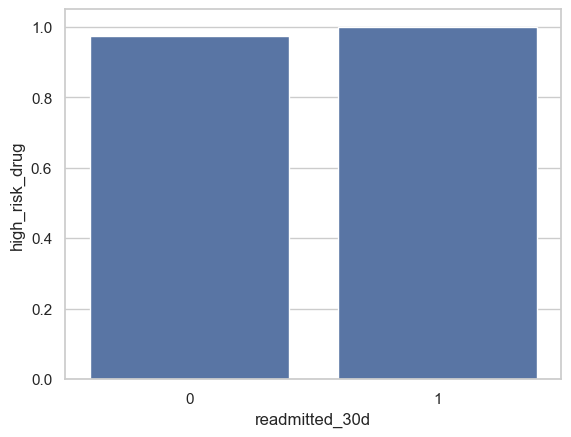

In [99]:
high_risk_rates = (
    df.groupby("readmitted_30d")["high_risk_drug"]
    .mean()
    .reset_index()
)

sns.barplot(
    data=high_risk_rates, x="readmitted_30d", y="high_risk_drug",
)

## Observations
- Non-readmitted patients (blue) show a clear peak at 20-30 unique medications and dominate the distribution due to class imbalance.
- Readmitted patients (orange) are sparse and relatively flat, appearing slightly right-shifted toward 40-70 drugs.
- The high-risk drug binary flag remains non-discriminative (~97% prevalence in both groups) and will be dropped as a feature.

## 10. Procedure Distribution
The number and type of procedures performed during admission could be a signal for readmission. I probably want procedure count as a feature and one hot encode the type of procedures for each patient.

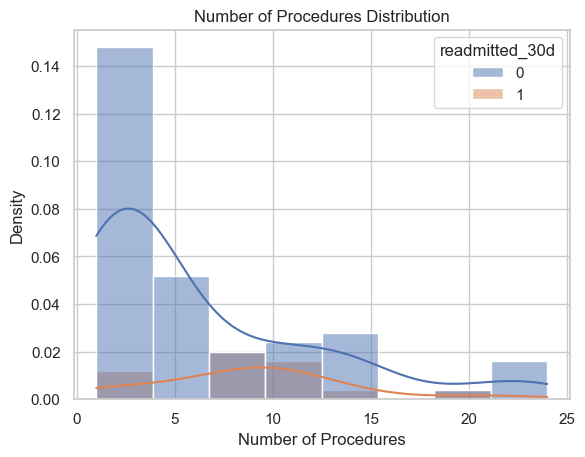

In [100]:
procedures = conn.execute('SELECT * FROM procedures_icd;').df()
procedure_codes = conn.execute('SELECT * FROM d_icd_procedures').df()

procedures = procedures.merge(procedure_codes[['icd_code', 'long_title']], on='icd_code', how='left')
procedure_counts = procedures.groupby('subject_id')['long_title'].nunique().reset_index().rename(columns={'long_title': 'n_procedures'})

df = df.merge(procedure_counts, on='subject_id', how='left')

sns.histplot(data=df, x='n_procedures', hue='readmitted_30d', kde=True, stat='density')
plt.title('Number of Procedures Distribution')
plt.xlabel('Number of Procedures')
plt.ylabel('Density')
plt.show()

## Observations
- Non-readmitted patients (blue) are heavily concentrated at 1-4 procedures, dropping off sharply after 5.
- Readmitted patients (orange) are flat and sparse, appearing more evenly distributed across the 1-25 range.

## 11. Correlation Matrix
Find the correlation coefficient for prospective features.

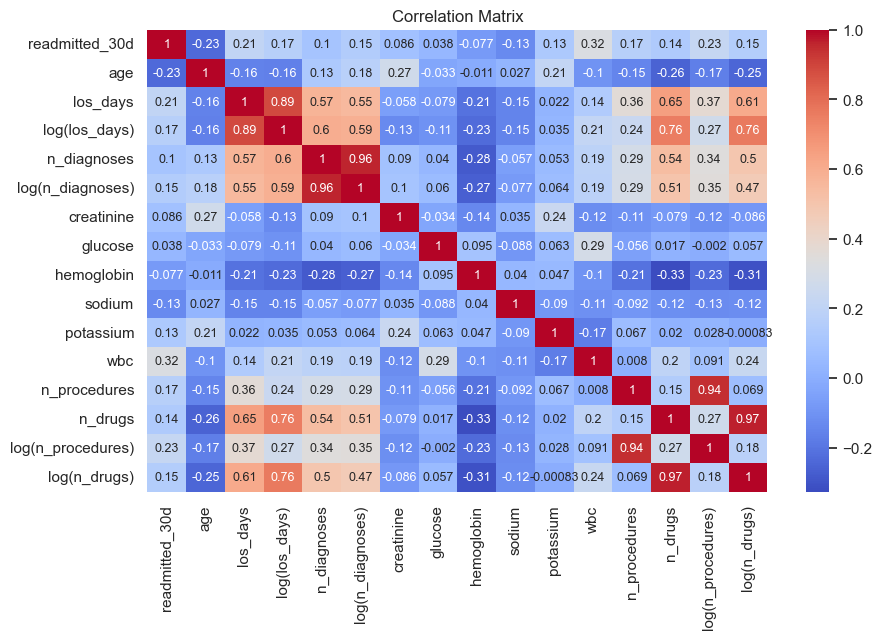

In [101]:
df['log(los_days)'] = np.log1p(df['los_days'])
df['log(n_diagnoses)'] = np.log1p(df['n_diagnoses'])
df['log(n_drugs)'] = np.log1p(df['n_drugs'])
df['log(n_procedures)'] = np.log1p(df['n_procedures'])

features = ['readmitted_30d', 'age', 'los_days', 'log(los_days)', 'n_diagnoses', 'log(n_diagnoses)',
            'creatinine', 'glucose', 'hemoglobin', 'sodium', 'potassium', 'wbc', 'n_procedures', 'n_drugs',
           'log(n_procedures)', 'log(n_drugs)']

plt.figure(figsize=(10, 6))
sns.heatmap(data=df[features].corr(), cmap='coolwarm', annot=True, annot_kws={'size': 9})
plt.title('Correlation Matrix')
plt.show()

## Observations
- **WBC** is the strongest individual predictor (r=0.32), followed by **log(n_procedures)** (r=0.23) and **log(los_days)** (r=0.17).
- **Age** shows a notable negative correlation (r=-0.23) — younger patients in this cohort are slightly more likely to be readmitted.
- **Hemoglobin** is negatively correlated (r=-0.077) — lower hemoglobin associated with higher readmission risk, consistent with clinical literature though the signal is weaker than expected.
- **Sodium** shows a negative correlation (r=-0.13) — lower sodium (hyponatremia) is a known marker of illness severity.
- To avoid multicollinearity, only log-transformed versions will be carried forward.
- Final feature set: `log(los_days)`, `log(n_diagnoses)`, `log(n_procedures)`, `log(n_drugs)`, `age`, `wbc`, `hemoglobin`, `creatinine`, `glucose`, `sodium`, `potassium`, and `gender`.